In [1]:
!pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 2.7 MB/s eta 0:00:00


In [2]:
import torch



class MLP(torch.nn.Module):
    """Multi-layer perceptron neural net.

    ## Parameters
    - **input_size** (*int*) - Dimension of the input layer.

    - **output_size** (*int*) - Dimension of the output layer.

    - **hidden_sizes** (*list[int], optional*) - Dimensions of hidden layers, if any.

    - **batch_norm** (*bool, optional*) - Whether to use batch normalization.

    ## Attributes
    - **net** (*torch.nn.ModuleList*) - List of layers
    """
    def __init__(self, input_size, output_size, hidden_sizes=[], batch_norm=False):
        """ """
        super().__init__()
        self.net = torch.nn.ModuleList([])
        layers = [input_size] + hidden_sizes + [output_size]
        for i in range(len(layers)-1):
            self.net.append(torch.nn.Linear(layers[i],layers[i+1]))
            if i != len(layers)-2: #all layers except last
                if batch_norm:
                    self.net.append(torch.nn.BatchNorm1d(layers[i+1]))
                self.net.append(torch.nn.ReLU())

    def forward(self, X) -> torch.Tensor:
        """Forward propagation of neural net.

        ## Parameters
        - **X** (*torch.Tensor, shape=(\\*,input_size)*) - Input data to net.

        ## Returns
        - **X** (*torch.Tensor, shape=(\\*,output_size)*) - Output data from net.
        """
        for layer in self.net:
            X = layer(X)
        return X


class AutoEncoder(torch.nn.Module):
    """AutoEncoder neural net. Contains an encoder connected to a decoder, both are multi-layer perceptrons.

    ## Parameters
    - **input_size** (*int*) - Number of dimensions in original data (encoder input) and reconstructed data (decoder output).

    - **encoded_size** (*int*) - Number of dimensions in encoded data (encoder output and decoder input).

    - **encoder_hidden_layers** (*list[int], optional*) - Encoder will have layers = `[input_size, *encoder_hidden_layers, encoded_size]`. If not set, defaults to reverse of `decoder_hidden_layers`. If that is also not set, defaults to `[]`.

    - **decoder_hidden_layers** (*list[int], optional*) - Decoder has layers = `[encoded_size, *decoder_hidden_layers, input_size]`. If not set, defaults to reverse of `encoder_hidden_layers`. If that is also not set, defaults to `[]`.

    - **batch_norm** (*bool, optional*): Whether to use batch normalization.

    ## Attributes
    - **encoder** - Encoder neural net.

    - **decoder** - Decoder neural net.
    """
    def __init__(self, input_size, encoded_size, encoder_hidden_layers=[], decoder_hidden_layers=[], batch_norm=False):
        """ """
        super().__init__()

        if not decoder_hidden_layers and encoder_hidden_layers:
            decoder_hidden_layers = encoder_hidden_layers[::-1]
        elif not encoder_hidden_layers and decoder_hidden_layers:
            encoder_hidden_layers = decoder_hidden_layers[::-1]

        self.encoder = MLP(
            input_size = input_size,
            output_size = encoded_size,
            hidden_sizes = encoder_hidden_layers,
            batch_norm = batch_norm
        )

        self.decoder = MLP(
            input_size = encoded_size,
            output_size = input_size,
            hidden_sizes = decoder_hidden_layers,
            batch_norm = batch_norm
        )

    def forward(self, X) -> tuple[torch.Tensor, torch.Tensor]:
        """Forward propagation of neural net.

        ## Parameters
        - **X** (*torch.Tensor, shape=(\\*,input_size)*) - Input data to encoder.

        ## Returns
        - **Y** (*torch.Tensor, shape=(\\*,encoded_size)*) - Encoded data, i.e. output from encoder, input to decoder.

        - **Xr** (*torch.Tensor, shape=(\\*,input_size)*) - Reconstructed data, i.e. output of decoder.
        """
        Y = self.encoder(X) # encoder complete output
        Xr = self.decoder(Y) # final reconstructed output
        return Y, Xr


class Knet(torch.nn.Module):
    """Linear neural net to approximate the Koopman matrix.

    Contains identically sized input and output layers, no hidden layers, no bias vector, and no activation function.

    ## Parameters
    - **size** (*int*) - Dimension of the input and output layer.

    ## Attributes
    - **net** (*torch.nn.ModuleList*) - The neural net.
    """
    def __init__(self, size):
        """ """
        super().__init__()
        self.net = torch.nn.Linear(
            in_features = size,
            out_features = size,
            bias = False
        )

    def forward(self, X) -> torch.Tensor:
        """Forward propagation of neural net.

        ## Parameters
        - **X** (*torch.Tensor, shape=(\\*, size)*) - Input data to net.

        ## Returns
        - **X** (*torch.Tensor, shape=(\\*, size)*) - Output data from net.
        """
        return self.net(X)

Epoch 001 | train total 45.90171 (predx 30.40715, latent 0.18733, recon 30.61444) | val total 0.45220
Epoch 005 | train total 0.25859 (predx 0.07769, latent 0.08599, recon 0.18983) | val total 0.25284
Epoch 010 | train total 0.25981 (predx 0.10846, latent 0.04938, recon 0.20393) | val total 0.17281
Epoch 015 | train total 0.16376 (predx 0.06188, latent 0.03927, recon 0.12521) | val total 0.15851
Epoch 020 | train total 0.11201 (predx 0.03952, latent 0.03261, recon 0.07975) | val total 0.11140
Epoch 025 | train total 0.09376 (predx 0.03475, latent 0.03011, recon 0.05782) | val total 0.08756
Epoch 030 | train total 0.07894 (predx 0.03035, latent 0.02478, recon 0.04761) | val total 0.08281
Epoch 035 | train total 0.07154 (predx 0.02964, latent 0.02174, recon 0.04032) | val total 0.07414
Epoch 040 | train total 0.06040 (predx 0.02517, latent 0.01842, recon 0.03363) | val total 0.06870


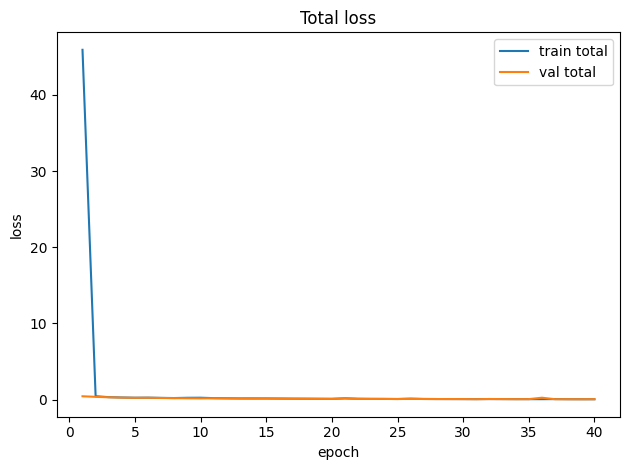

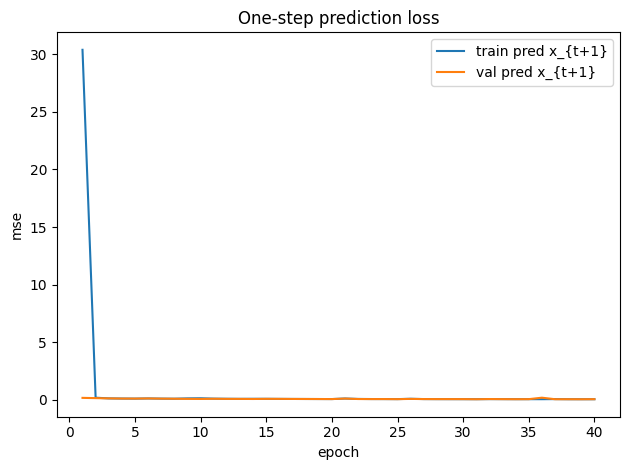

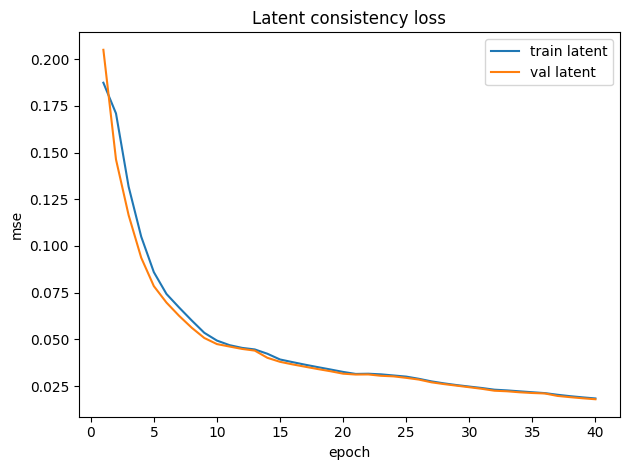

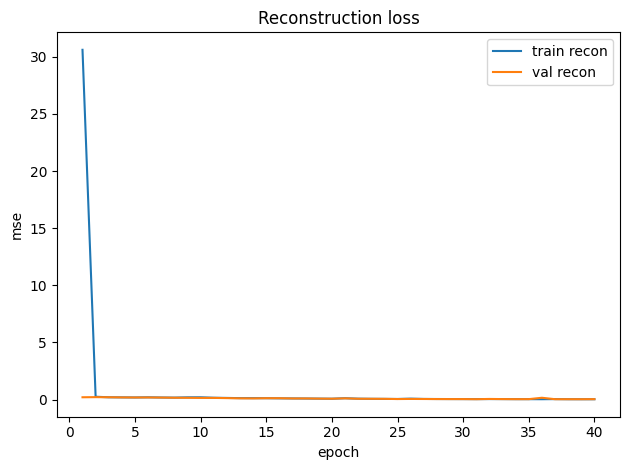

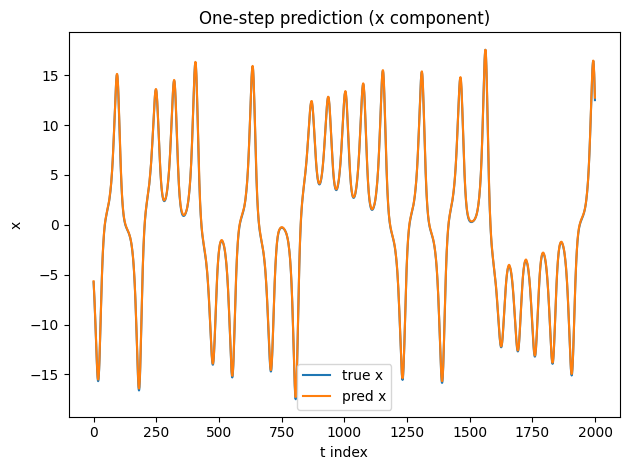

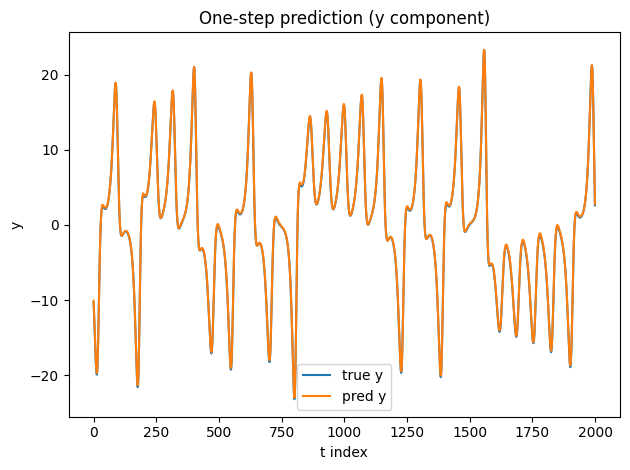

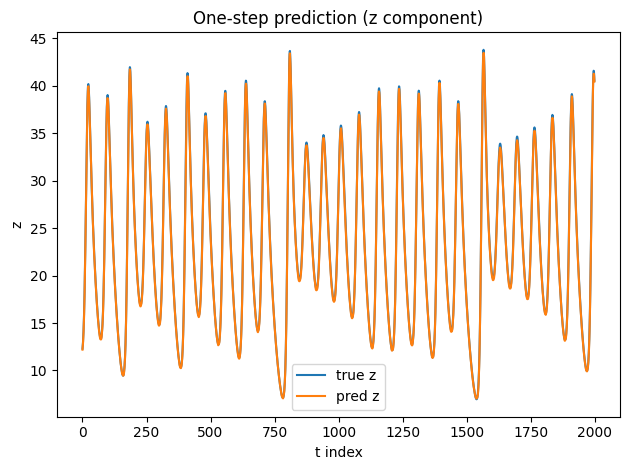

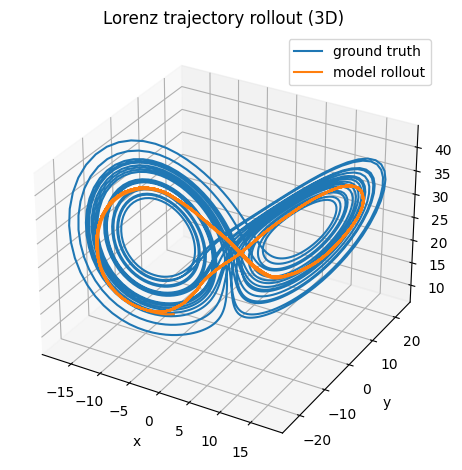

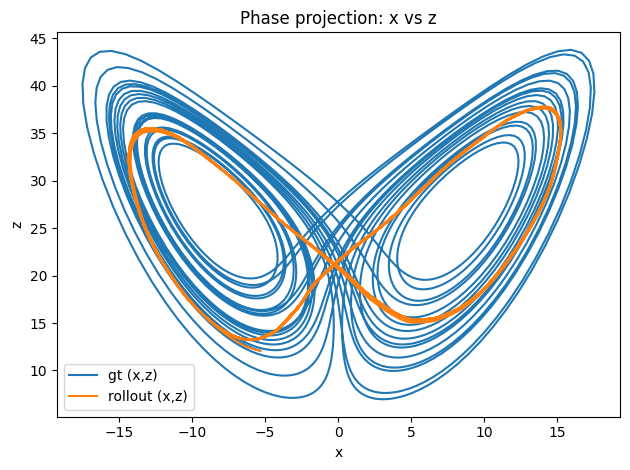

In [3]:
import math
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# -----------------------------
# Your modules (unchanged)
# -----------------------------
class MLP(torch.nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=[], batch_norm=False):
        super().__init__()
        self.net = torch.nn.ModuleList([])
        layers = [input_size] + hidden_sizes + [output_size]
        for i in range(len(layers)-1):
            self.net.append(torch.nn.Linear(layers[i], layers[i+1]))
            if i != len(layers)-2:
                if batch_norm:
                    self.net.append(torch.nn.BatchNorm1d(layers[i+1]))
                self.net.append(torch.nn.ReLU())

    def forward(self, X) -> torch.Tensor:
        for layer in self.net:
            X = layer(X)
        return X


class AutoEncoder(torch.nn.Module):
    def __init__(self, input_size, encoded_size, encoder_hidden_layers=[], decoder_hidden_layers=[], batch_norm=False):
        super().__init__()

        if not decoder_hidden_layers and encoder_hidden_layers:
            decoder_hidden_layers = encoder_hidden_layers[::-1]
        elif not encoder_hidden_layers and decoder_hidden_layers:
            encoder_hidden_layers = decoder_hidden_layers[::-1]

        self.encoder = MLP(
            input_size=input_size,
            output_size=encoded_size,
            hidden_sizes=encoder_hidden_layers,
            batch_norm=batch_norm
        )

        self.decoder = MLP(
            input_size=encoded_size,
            output_size=input_size,
            hidden_sizes=decoder_hidden_layers,
            batch_norm=batch_norm
        )

    def forward(self, X) -> tuple[torch.Tensor, torch.Tensor]:
        Y = self.encoder(X)
        Xr = self.decoder(Y)
        return Y, Xr


class Knet(torch.nn.Module):
    def __init__(self, size):
        super().__init__()
        self.net = torch.nn.Linear(size, size, bias=False)

    def forward(self, X) -> torch.Tensor:
        return self.net(X)

# -----------------------------
# Lorenz system + RK4 generator
# -----------------------------
def lorenz_rhs(x, sigma=10.0, rho=28.0, beta=8.0/3.0):
    # x: (..., 3)
    x1, x2, x3 = x[..., 0], x[..., 1], x[..., 2]
    dx1 = sigma * (x2 - x1)
    dx2 = x1 * (rho - x3) - x2
    dx3 = x1 * x2 - beta * x3
    return torch.stack([dx1, dx2, dx3], dim=-1)

@torch.no_grad()
def rk4_step(x, dt, rhs_fn):
    k1 = rhs_fn(x)
    k2 = rhs_fn(x + 0.5 * dt * k1)
    k3 = rhs_fn(x + 0.5 * dt * k2)
    k4 = rhs_fn(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

@torch.no_grad()
def simulate_lorenz(
    n_traj=50,
    n_steps=5000,
    dt=0.01,
    burn_in=200,
    init_box=([-20, -30, 0], [20, 30, 50]),
    device="cpu"
):
    """
    Returns:
        X: (n_traj, n_steps, 3) after burn-in
    """
    lo = torch.tensor(init_box[0], dtype=torch.float32, device=device)
    hi = torch.tensor(init_box[1], dtype=torch.float32, device=device)

    x0 = lo + (hi - lo) * torch.rand(n_traj, 3, device=device)
    x = x0.clone()

    # burn in to get onto attractor
    for _ in range(burn_in):
        x = rk4_step(x, dt, lorenz_rhs)

    traj = torch.zeros(n_traj, n_steps, 3, device=device)
    for t in range(n_steps):
        traj[:, t, :] = x
        x = rk4_step(x, dt, lorenz_rhs)

    return traj

# -----------------------------
# Dataset of (x_t, x_{t+1})
# -----------------------------
class PairDataset(Dataset):
    def __init__(self, traj: torch.Tensor):
        """
        traj: (n_traj, n_steps, 3)
        Uses pairs (t -> t+1)
        """
        self.traj = traj
        self.n_traj, self.n_steps, self.d = traj.shape
        self.n_pairs = self.n_traj * (self.n_steps - 1)

    def __len__(self):
        return self.n_pairs

    def __getitem__(self, idx):
        traj_id = idx // (self.n_steps - 1)
        t = idx % (self.n_steps - 1)
        x_t = self.traj[traj_id, t]
        x_tp1 = self.traj[traj_id, t + 1]
        return x_t, x_tp1

# -----------------------------
# Continuous-time Deep Koopman wrapper
# Learn generator A; propagate via expm(A dt)
# -----------------------------
class DeepKoopmanCT(torch.nn.Module):
    def __init__(self, autoencoder: AutoEncoder, latent_dim: int):
        super().__init__()
        self.ae = autoencoder
        self.K = Knet(latent_dim)  # we interpret weights as generator A

    def generator_matrix(self):
        # A is the weight matrix of the linear layer: out = x @ A^T
        # So K.net.weight has shape (latent_dim, latent_dim) and represents A in transpose form.
        # We'll build A so that z_next = expm(A dt) z
        return self.K.net.weight

    def expm_propagate(self, z_t, dt):
        # z_t: (B, d)
        A = self.generator_matrix()  # (d, d)
        M = torch.matrix_exp(A * dt) # (d, d)
        # We want z_next = z_t @ M^T if z is row-vector batch
        return z_t @ M.T

    def forward_one_step(self, x_t, dt):
        z_t, x_t_rec = self.ae(x_t)
        z_tp1_pred = self.expm_propagate(z_t, dt)
        x_tp1_pred = self.ae.decoder(z_tp1_pred)
        return {
            "z_t": z_t,
            "x_t_rec": x_t_rec,
            "z_tp1_pred": z_tp1_pred,
            "x_tp1_pred": x_tp1_pred,
        }

# -----------------------------
# Training utilities
# -----------------------------
def set_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

def rollout(model: DeepKoopmanCT, x0, dt, steps):
    """
    Autoregressive rollout in x-space:
    x_{t+1} = decoder(expm(A dt) encoder(x_t))
    """
    xs = [x0]
    x = x0
    for _ in range(steps):
        out = model.forward_one_step(x.unsqueeze(0), dt)
        x = out["x_tp1_pred"].squeeze(0)
        xs.append(x)
    return torch.stack(xs, dim=0)  # (steps+1, 3)

def train_deep_koopman_ct(
    device="cuda" if torch.cuda.is_available() else "cpu",
    dt=0.01,
    n_traj=50,
    n_steps=5000,
    burn_in=200,
    batch_size=2048,
    epochs=50,
    lr=1e-3,
    latent_dim=8,
    enc_hidden=[128, 128],
    dec_hidden=[128, 128],
    batch_norm=False,
    alpha_latent=1.0,   # weight for latent consistency
    beta_recon=1.0,     # weight for reconstruction
    gamma_predx=1.0,    # weight for x_{t+1} prediction
    grad_clip=1.0,
    seed=0,
):
    set_seed(seed)

    # Generate data
    traj = simulate_lorenz(
        n_traj=n_traj, n_steps=n_steps, dt=dt, burn_in=burn_in, device=device
    )

    # simple train/val split by trajectories
    n_train = int(0.8 * n_traj)
    train_traj = traj[:n_train].contiguous()
    val_traj   = traj[n_train:].contiguous()

    train_ds = PairDataset(train_traj)
    val_ds   = PairDataset(val_traj)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_dl   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    # Model
    ae = AutoEncoder(
        input_size=3,
        encoded_size=latent_dim,
        encoder_hidden_layers=enc_hidden,
        decoder_hidden_layers=dec_hidden,
        batch_norm=batch_norm
    ).to(device)

    model = DeepKoopmanCT(ae, latent_dim=latent_dim).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse = torch.nn.MSELoss()

    history = {
        "train_total": [],
        "train_predx": [],
        "train_latent": [],
        "train_recon": [],
        "val_total": [],
        "val_predx": [],
        "val_latent": [],
        "val_recon": [],
    }

    def eval_loop():
        model.eval()
        totals = []
        predxs = []
        latents = []
        recons = []
        with torch.no_grad():
            for x_t, x_tp1 in val_dl:
                x_t = x_t.to(device)
                x_tp1 = x_tp1.to(device)

                # One-step
                out = model.forward_one_step(x_t, dt)

                # Encode true next
                z_tp1_true = model.ae.encoder(x_tp1)

                # Losses
                loss_predx  = mse(out["x_tp1_pred"], x_tp1)
                loss_latent = mse(out["z_tp1_pred"], z_tp1_true)
                loss_recon  = mse(out["x_t_rec"], x_t)

                loss_total = gamma_predx*loss_predx + alpha_latent*loss_latent + beta_recon*loss_recon

                totals.append(loss_total.item())
                predxs.append(loss_predx.item())
                latents.append(loss_latent.item())
                recons.append(loss_recon.item())

        return (
            float(np.mean(totals)),
            float(np.mean(predxs)),
            float(np.mean(latents)),
            float(np.mean(recons)),
        )

    # Training loop
    for ep in range(1, epochs + 1):
        model.train()
        totals = []
        predxs = []
        latents = []
        recons = []

        for x_t, x_tp1 in train_dl:
            x_t = x_t.to(device)
            x_tp1 = x_tp1.to(device)

            out = model.forward_one_step(x_t, dt)
            z_tp1_true = model.ae.encoder(x_tp1)

            loss_predx  = mse(out["x_tp1_pred"], x_tp1)
            loss_latent = mse(out["z_tp1_pred"], z_tp1_true)
            loss_recon  = mse(out["x_t_rec"], x_t)

            loss_total = gamma_predx*loss_predx + alpha_latent*loss_latent + beta_recon*loss_recon

            opt.zero_grad(set_to_none=True)
            loss_total.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            totals.append(loss_total.item())
            predxs.append(loss_predx.item())
            latents.append(loss_latent.item())
            recons.append(loss_recon.item())

        val_total, val_predx, val_latent, val_recon = eval_loop()

        history["train_total"].append(float(np.mean(totals)))
        history["train_predx"].append(float(np.mean(predxs)))
        history["train_latent"].append(float(np.mean(latents)))
        history["train_recon"].append(float(np.mean(recons)))

        history["val_total"].append(val_total)
        history["val_predx"].append(val_predx)
        history["val_latent"].append(val_latent)
        history["val_recon"].append(val_recon)

        if ep == 1 or ep % 5 == 0 or ep == epochs:
            print(
                f"Epoch {ep:03d} | "
                f"train total {history['train_total'][-1]:.5f} (predx {history['train_predx'][-1]:.5f}, "
                f"latent {history['train_latent'][-1]:.5f}, recon {history['train_recon'][-1]:.5f}) | "
                f"val total {val_total:.5f}"
            )

    # Return artifacts for plotting/inspection
    return model, history, train_traj.detach().cpu(), val_traj.detach().cpu(), dt

# -----------------------------
# Plotting
# -----------------------------
def make_plots(model, history, train_traj, val_traj, dt, rollout_steps=2000):
    # 1) Loss curves
    epochs = np.arange(1, len(history["train_total"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_total"], label="train total")
    plt.plot(epochs, history["val_total"], label="val total")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Total loss")
    plt.legend(); plt.tight_layout()

    plt.figure()
    plt.plot(epochs, history["train_predx"], label="train pred x_{t+1}")
    plt.plot(epochs, history["val_predx"], label="val pred x_{t+1}")
    plt.xlabel("epoch"); plt.ylabel("mse"); plt.title("One-step prediction loss")
    plt.legend(); plt.tight_layout()

    plt.figure()
    plt.plot(epochs, history["train_latent"], label="train latent")
    plt.plot(epochs, history["val_latent"], label="val latent")
    plt.xlabel("epoch"); plt.ylabel("mse"); plt.title("Latent consistency loss")
    plt.legend(); plt.tight_layout()

    plt.figure()
    plt.plot(epochs, history["train_recon"], label="train recon")
    plt.plot(epochs, history["val_recon"], label="val recon")
    plt.xlabel("epoch"); plt.ylabel("mse"); plt.title("Reconstruction loss")
    plt.legend(); plt.tight_layout()

    # 2) One-step prediction trace on a single validation trajectory segment
    model.eval()
    device = next(model.parameters()).device

    # pick one validation trajectory
    x_true = val_traj[0]  # (T,3)
    T = min(2000, x_true.shape[0] - 1)
    x_t = torch.from_numpy(x_true[:T].numpy()).to(device)
    x_tp1 = torch.from_numpy(x_true[1:T+1].numpy()).to(device)

    with torch.no_grad():
        out = model.forward_one_step(x_t, dt)
        x_pred = out["x_tp1_pred"].cpu().numpy()

    x_tp1_np = x_tp1.cpu().numpy()

    plt.figure()
    plt.plot(x_tp1_np[:, 0], label="true x")
    plt.plot(x_pred[:, 0], label="pred x")
    plt.title("One-step prediction (x component)")
    plt.xlabel("t index"); plt.ylabel("x")
    plt.legend(); plt.tight_layout()

    plt.figure()
    plt.plot(x_tp1_np[:, 1], label="true y")
    plt.plot(x_pred[:, 1], label="pred y")
    plt.title("One-step prediction (y component)")
    plt.xlabel("t index"); plt.ylabel("y")
    plt.legend(); plt.tight_layout()

    plt.figure()
    plt.plot(x_tp1_np[:, 2], label="true z")
    plt.plot(x_pred[:, 2], label="pred z")
    plt.title("One-step prediction (z component)")
    plt.xlabel("t index"); plt.ylabel("z")
    plt.legend(); plt.tight_layout()

    # 3) Multi-step rollout vs ground truth (autoregressive)
    x0 = torch.from_numpy(val_traj[0, 0].numpy()).to(device)
    with torch.no_grad():
        x_roll = rollout(model, x0, dt, steps=rollout_steps).cpu().numpy()

    x_gt = val_traj[0, :rollout_steps+1].numpy()

    # 3D plot (requires mpl_toolkits, but standard in matplotlib)
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(x_gt[:, 0], x_gt[:, 1], x_gt[:, 2], label="ground truth")
    ax.plot(x_roll[:, 0], x_roll[:, 1], x_roll[:, 2], label="model rollout")
    ax.set_title("Lorenz trajectory rollout (3D)")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.legend()
    plt.tight_layout()

    # Phase projections
    plt.figure()
    plt.plot(x_gt[:, 0], x_gt[:, 2], label="gt (x,z)")
    plt.plot(x_roll[:, 0], x_roll[:, 2], label="rollout (x,z)")
    plt.xlabel("x"); plt.ylabel("z")
    plt.title("Phase projection: x vs z")
    plt.legend(); plt.tight_layout()

    plt.show()

# -----------------------------
# Run it
# -----------------------------
if __name__ == "__main__":
    model, history, train_traj, val_traj, dt = train_deep_koopman_ct(
        dt=0.01,
        n_traj=60,
        n_steps=6000,
        burn_in=300,
        batch_size=2048,
        epochs=40,
        lr=1e-3,
        latent_dim=10,
        enc_hidden=[128, 128],
        dec_hidden=[128, 128],
        batch_norm=False,
        alpha_latent=1.0,
        beta_recon=0.5,
        gamma_predx=1.0,
        grad_clip=1.0,
        seed=0,
    )

    make_plots(model, history, train_traj, val_traj, dt, rollout_steps=2500)

In [ ]:
### Experiment with KANs just going the same shape.
import math
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from kan import KAN

# -----------------------------
# Your modules (unchanged)
# -----------------------------
class MLP(torch.nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=[], batch_norm=False):
        super().__init__()
        self.net = torch.nn.ModuleList([])
        layers = [input_size] + hidden_sizes + [output_size]
        for i in range(len(layers)-1):
            self.net.append(torch.nn.Linear(layers[i], layers[i+1]))
            if i != len(layers)-2:
                if batch_norm:
                    self.net.append(torch.nn.BatchNorm1d(layers[i+1]))
                self.net.append(torch.nn.ReLU())

    def forward(self, X) -> torch.Tensor:
        for layer in self.net:
            X = layer(X)
        return X


# class AutoEncoder(torch.nn.Module):
#     def __init__(self, input_size, encoded_size, encoder_hidden_layers=[], decoder_hidden_layers=[], batch_norm=False):
#         super().__init__()

#         if not decoder_hidden_layers and encoder_hidden_layers:
#             decoder_hidden_layers = encoder_hidden_layers[::-1]
#         elif not encoder_hidden_layers and decoder_hidden_layers:
#             encoder_hidden_layers = decoder_hidden_layers[::-1]

#         self.encoder = MLP(
#             input_size=input_size,
#             output_size=encoded_size,
#             hidden_sizes=encoder_hidden_layers,
#             batch_norm=batch_norm
#         )

#         self.decoder = MLP(
#             input_size=encoded_size,
#             output_size=input_size,
#             hidden_sizes=decoder_hidden_layers,
#             batch_norm=batch_norm
#         )

#     def forward(self, X) -> tuple[torch.Tensor, torch.Tensor]:
#         Y = self.encoder(X)
#         Xr = self.decoder(Y)
#         return Y, Xr
class AutoEncoder(torch.nn.Module):
    def __init__(
        self,
        input_size: int,
        encoded_size: int,
        encoder_hidden_layers=None,
        decoder_hidden_layers=None,
        *,
        grid: int = 5,
        k: int = 3,
        seed: int = 0,
        # optionally: grid_eps=1.0, grid_range=[-1, 1], etc.
    ):
        super().__init__()
        encoder_hidden_layers = encoder_hidden_layers or []
        decoder_hidden_layers = decoder_hidden_layers or []

        # mirror if only one side given (same logic you had)
        if not decoder_hidden_layers and encoder_hidden_layers:
            decoder_hidden_layers = encoder_hidden_layers[::-1]
        elif not encoder_hidden_layers and decoder_hidden_layers:
            encoder_hidden_layers = decoder_hidden_layers[::-1]

        # widths are [dim_in, ..., dim_out]
        # enc_width = [input_size, *encoder_hidden_layers, encoded_size]
        #dec_width = [encoded_size, *decoder_hidden_layers, input_size]

        enc_width = [input_size, 16, encoded_size]
        dec_width = [encoded_size, 16, input_size]
        rbf = lambda x: torch.exp(-x**2)
        k = 1
        grid = 4
        self.encoder = KAN(width=enc_width, grid=grid, base_fun=rbf, k=k, seed=seed)
        self.decoder = KAN(width=dec_width, grid=grid, base_fun=rbf, k=k, seed=seed)

    def forward(self, X):
        Y = self.encoder(X)   # (batch, encoded_size)
        Xr = self.decoder(Y)  # (batch, input_size)
        return Y, Xr

class Knet(torch.nn.Module):
    def __init__(self, size):
        super().__init__()
        self.net = torch.nn.Linear(size, size, bias=False)

    def forward(self, X) -> torch.Tensor:
        return self.net(X)

# -----------------------------
# Lorenz system + RK4 generator
# -----------------------------
def lorenz_rhs(x, sigma=10.0, rho=28.0, beta=8.0/3.0):
    # x: (..., 3)
    x1, x2, x3 = x[..., 0], x[..., 1], x[..., 2]
    dx1 = sigma * (x2 - x1)
    dx2 = x1 * (rho - x3) - x2
    dx3 = x1 * x2 - beta * x3
    return torch.stack([dx1, dx2, dx3], dim=-1)

@torch.no_grad()
def rk4_step(x, dt, rhs_fn):
    k1 = rhs_fn(x)
    k2 = rhs_fn(x + 0.5 * dt * k1)
    k3 = rhs_fn(x + 0.5 * dt * k2)
    k4 = rhs_fn(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

@torch.no_grad()
def simulate_lorenz(
    n_traj=50,
    n_steps=5000,
    dt=0.01,
    burn_in=200,
    init_box=([-20, -30, 0], [20, 30, 50]),
    device="cpu"
):
    """
    Returns:
        X: (n_traj, n_steps, 3) after burn-in
    """
    lo = torch.tensor(init_box[0], dtype=torch.float32, device=device)
    hi = torch.tensor(init_box[1], dtype=torch.float32, device=device)

    x0 = lo + (hi - lo) * torch.rand(n_traj, 3, device=device)
    x = x0.clone()

    # burn in to get onto attractor
    for _ in range(burn_in):
        x = rk4_step(x, dt, lorenz_rhs)

    traj = torch.zeros(n_traj, n_steps, 3, device=device)
    for t in range(n_steps):
        traj[:, t, :] = x
        x = rk4_step(x, dt, lorenz_rhs)

    return traj

# -----------------------------
# Dataset of (x_t, x_{t+1})
# -----------------------------
class PairDataset(Dataset):
    def __init__(self, traj: torch.Tensor):
        """
        traj: (n_traj, n_steps, 3)
        Uses pairs (t -> t+1)
        """
        self.traj = traj
        self.n_traj, self.n_steps, self.d = traj.shape
        self.n_pairs = self.n_traj * (self.n_steps - 1)

    def __len__(self):
        return self.n_pairs

    def __getitem__(self, idx):
        traj_id = idx // (self.n_steps - 1)
        t = idx % (self.n_steps - 1)
        x_t = self.traj[traj_id, t]
        x_tp1 = self.traj[traj_id, t + 1]
        return x_t, x_tp1

# -----------------------------
# Continuous-time Deep Koopman wrapper
# Learn generator A; propagate via expm(A dt)
# -----------------------------
class DeepKoopmanCT(torch.nn.Module):
    def __init__(self, autoencoder: AutoEncoder, latent_dim: int):
        super().__init__()
        self.ae = autoencoder
        self.K = Knet(latent_dim)  # we interpret weights as generator A

    def generator_matrix(self):
        # A is the weight matrix of the linear layer: out = x @ A^T
        # So K.net.weight has shape (latent_dim, latent_dim) and represents A in transpose form.
        # We'll build A so that z_next = expm(A dt) z
        return self.K.net.weight

    def expm_propagate(self, z_t, dt):
        # z_t: (B, d)
        A = self.generator_matrix()  # (d, d)
        M = torch.matrix_exp(A * dt) # (d, d)
        # We want z_next = z_t @ M^T if z is row-vector batch
        return z_t @ M.T

    def forward_one_step(self, x_t, dt):
        z_t, x_t_rec = self.ae(x_t)
        z_tp1_pred = self.expm_propagate(z_t, dt)
        x_tp1_pred = self.ae.decoder(z_tp1_pred)
        return {
            "z_t": z_t,
            "x_t_rec": x_t_rec,
            "z_tp1_pred": z_tp1_pred,
            "x_tp1_pred": x_tp1_pred,
        }

# -----------------------------
# Training utilities
# -----------------------------
def set_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

def rollout(model: DeepKoopmanCT, x0, dt, steps):
    """
    Autoregressive rollout in x-space:
    x_{t+1} = decoder(expm(A dt) encoder(x_t))
    """
    xs = [x0]
    x = x0
    for _ in range(steps):
        out = model.forward_one_step(x.unsqueeze(0), dt)
        x = out["x_tp1_pred"].squeeze(0)
        xs.append(x)
    return torch.stack(xs, dim=0)  # (steps+1, 3)

def train_deep_koopman_ct(
    device="cuda" if torch.cuda.is_available() else "cpu",
    dt=0.01,
    n_traj=50,
    n_steps=5000,
    burn_in=200,
    batch_size=2048,
    epochs=50,
    lr=1e-3,
    latent_dim=8,
    enc_hidden=[128, 128],
    dec_hidden=[128, 128],
    batch_norm=False,
    alpha_latent=1.0,   # weight for latent consistency
    beta_recon=1.0,     # weight for reconstruction
    gamma_predx=1.0,    # weight for x_{t+1} prediction
    grad_clip=1.0,
    seed=0,
):
    set_seed(seed)

    # Generate data
    traj = simulate_lorenz(
        n_traj=n_traj, n_steps=n_steps, dt=dt, burn_in=burn_in, device=device
    )

    # simple train/val split by trajectories
    n_train = int(0.8 * n_traj)
    train_traj = traj[:n_train].contiguous()
    val_traj   = traj[n_train:].contiguous()

    train_ds = PairDataset(train_traj)
    val_ds   = PairDataset(val_traj)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_dl   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    # Model
    ae = AutoEncoder(
        input_size=3,
        encoded_size=latent_dim,
        encoder_hidden_layers=enc_hidden,
        decoder_hidden_layers=dec_hidden,
        #batch_norm=batch_norm
    ).to(device)
    # ae = KAN([input_size, encoded_size=latent_dim,
    #     encoder_hidden_layers=enc_hidden,
    #     decoder_hidden_layers=dec_hidden,]
    # ).to(device)

    model = DeepKoopmanCT(ae, latent_dim=latent_dim).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse = torch.nn.MSELoss()

    history = {
        "train_total": [],
        "train_predx": [],
        "train_latent": [],
        "train_recon": [],
        "val_total": [],
        "val_predx": [],
        "val_latent": [],
        "val_recon": [],
    }

    def eval_loop():
        model.eval()
        totals = []
        predxs = []
        latents = []
        recons = []
        with torch.no_grad():
            for x_t, x_tp1 in val_dl:
                x_t = x_t.to(device)
                x_tp1 = x_tp1.to(device)

                # One-step
                out = model.forward_one_step(x_t, dt)

                # Encode true next
                z_tp1_true = model.ae.encoder(x_tp1)

                # Losses
                loss_predx  = mse(out["x_tp1_pred"], x_tp1)
                loss_latent = mse(out["z_tp1_pred"], z_tp1_true)
                loss_recon  = mse(out["x_t_rec"], x_t)

                loss_total = gamma_predx*loss_predx + alpha_latent*loss_latent + beta_recon*loss_recon

                totals.append(loss_total.item())
                predxs.append(loss_predx.item())
                latents.append(loss_latent.item())
                recons.append(loss_recon.item())

        return (
            float(np.mean(totals)),
            float(np.mean(predxs)),
            float(np.mean(latents)),
            float(np.mean(recons)),
        )

    # Training loop
    for ep in range(1, epochs + 1):
        model.train()
        totals = []
        predxs = []
        latents = []
        recons = []

        for x_t, x_tp1 in train_dl:
            x_t = x_t.to(device)
            x_tp1 = x_tp1.to(device)

            out = model.forward_one_step(x_t, dt)
            z_tp1_true = model.ae.encoder(x_tp1)

            loss_predx  = mse(out["x_tp1_pred"], x_tp1)
            loss_latent = mse(out["z_tp1_pred"], z_tp1_true)
            loss_recon  = mse(out["x_t_rec"], x_t)

            loss_total = gamma_predx*loss_predx + alpha_latent*loss_latent + beta_recon*loss_recon

            opt.zero_grad(set_to_none=True)
            loss_total.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            totals.append(loss_total.item())
            predxs.append(loss_predx.item())
            latents.append(loss_latent.item())
            recons.append(loss_recon.item())

        val_total, val_predx, val_latent, val_recon = eval_loop()

        history["train_total"].append(float(np.mean(totals)))
        history["train_predx"].append(float(np.mean(predxs)))
        history["train_latent"].append(float(np.mean(latents)))
        history["train_recon"].append(float(np.mean(recons)))

        history["val_total"].append(val_total)
        history["val_predx"].append(val_predx)
        history["val_latent"].append(val_latent)
        history["val_recon"].append(val_recon)

        if ep == 1 or ep % 5 == 0 or ep == epochs:
            print(
                f"Epoch {ep:03d} | "
                f"train total {history['train_total'][-1]:.5f} (predx {history['train_predx'][-1]:.5f}, "
                f"latent {history['train_latent'][-1]:.5f}, recon {history['train_recon'][-1]:.5f}) | "
                f"val total {val_total:.5f}"
            )

    # Return artifacts for plotting/inspection
    return model, history, train_traj.detach().cpu(), val_traj.detach().cpu(), dt

# -----------------------------
# Plotting
# -----------------------------
def make_plots(model, history, train_traj, val_traj, dt, rollout_steps=2000):
    # 1) Loss curves
    epochs = np.arange(1, len(history["train_total"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_total"], label="train total")
    plt.plot(epochs, history["val_total"], label="val total")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Total loss")
    plt.legend(); plt.tight_layout()

    plt.figure()
    plt.plot(epochs, history["train_predx"], label="train pred x_{t+1}")
    plt.plot(epochs, history["val_predx"], label="val pred x_{t+1}")
    plt.xlabel("epoch"); plt.ylabel("mse"); plt.title("One-step prediction loss")
    plt.legend(); plt.tight_layout()

    plt.figure()
    plt.plot(epochs, history["train_latent"], label="train latent")
    plt.plot(epochs, history["val_latent"], label="val latent")
    plt.xlabel("epoch"); plt.ylabel("mse"); plt.title("Latent consistency loss")
    plt.legend(); plt.tight_layout()

    plt.figure()
    plt.plot(epochs, history["train_recon"], label="train recon")
    plt.plot(epochs, history["val_recon"], label="val recon")
    plt.xlabel("epoch"); plt.ylabel("mse"); plt.title("Reconstruction loss")
    plt.legend(); plt.tight_layout()

    # 2) One-step prediction trace on a single validation trajectory segment
    model.eval()
    device = next(model.parameters()).device

    # pick one validation trajectory
    x_true = val_traj[0]  # (T,3)
    T = min(2000, x_true.shape[0] - 1)
    x_t = torch.from_numpy(x_true[:T].numpy()).to(device)
    x_tp1 = torch.from_numpy(x_true[1:T+1].numpy()).to(device)

    with torch.no_grad():
        out = model.forward_one_step(x_t, dt)
        x_pred = out["x_tp1_pred"].cpu().numpy()

    x_tp1_np = x_tp1.cpu().numpy()

    plt.figure()
    plt.plot(x_tp1_np[:, 0], label="true x")
    plt.plot(x_pred[:, 0], label="pred x")
    plt.title("One-step prediction (x component)")
    plt.xlabel("t index"); plt.ylabel("x")
    plt.legend(); plt.tight_layout()

    plt.figure()
    plt.plot(x_tp1_np[:, 1], label="true y")
    plt.plot(x_pred[:, 1], label="pred y")
    plt.title("One-step prediction (y component)")
    plt.xlabel("t index"); plt.ylabel("y")
    plt.legend(); plt.tight_layout()

    plt.figure()
    plt.plot(x_tp1_np[:, 2], label="true z")
    plt.plot(x_pred[:, 2], label="pred z")
    plt.title("One-step prediction (z component)")
    plt.xlabel("t index"); plt.ylabel("z")
    plt.legend(); plt.tight_layout()

    # 3) Multi-step rollout vs ground truth (autoregressive)
    x0 = torch.from_numpy(val_traj[0, 0].numpy()).to(device)
    with torch.no_grad():
        x_roll = rollout(model, x0, dt, steps=rollout_steps).cpu().numpy()

    x_gt = val_traj[0, :rollout_steps+1].numpy()

    # 3D plot (requires mpl_toolkits, but standard in matplotlib)
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(x_gt[:, 0], x_gt[:, 1], x_gt[:, 2], label="ground truth")
    ax.plot(x_roll[:, 0], x_roll[:, 1], x_roll[:, 2], label="model rollout")
    ax.set_title("Lorenz trajectory rollout (3D)")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.legend()
    plt.tight_layout()

    # Phase projections
    plt.figure()
    plt.plot(x_gt[:, 0], x_gt[:, 2], label="gt (x,z)")
    plt.plot(x_roll[:, 0], x_roll[:, 2], label="rollout (x,z)")
    plt.xlabel("x"); plt.ylabel("z")
    plt.title("Phase projection: x vs z")
    plt.legend(); plt.tight_layout()

    plt.show()

# -----------------------------
# Run it
# -----------------------------
if __name__ == "__main__":
    model, history, train_traj, val_traj, dt = train_deep_koopman_ct(
        dt=0.01,
        n_traj=60,
        n_steps=6000,
        burn_in=300,
        batch_size=500,#2048,
        epochs=100,
        lr=1e-3,
        latent_dim=7,
        # enc_hidden=[128, 128],
        # dec_hidden=[128, 128],
        enc_hidden=[16, 16],
        dec_hidden=[16, 16],
        batch_norm=False,
        alpha_latent=1.0,
        beta_recon=1.0,
        gamma_predx=1.0,
        grad_clip=1.0,
        seed=0,
    )

    make_plots(model, history, train_traj, val_traj, dt, rollout_steps=2500)

checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
Epoch 001 | train total 329.26215 (predx 164.62844, latent 0.00002, recon 164.63369) | val total 179.65563
Epoch 005 | train total 134.00448 (predx 66.96087, latent 0.00989, recon 67.03372) | val total 134.45146
Epoch 010 | train total 133.21467 (predx 66.55267, latent 0.01981, recon 66.64219) | val total 132.28656
Epoch 015 | train total 132.79461 (predx 66.33699, latent 0.02937, recon 66.42825) | val total 131.94651
Epoch 020 | train total 132.36959 (predx 66.11678, latent 0.03881, recon 66.21400) | val total 132.26992
